# EC-Earth CCN–CDNC susceptibility: sampling, binning, and structure comparison

**Scientific question.** For the EC-Earth/TM5 stations, how does the
aerosol–cloud susceptibility $\beta = \mathrm{d}\ln(\mathrm{CDNC}) /
\mathrm{d}\ln(\mathrm{CCN})$ depend on (a) *where* it is measured in the
vertical (every level vs. column-integrated), (b) the per-bin aggregation
statistic, and (c) whether the relationship is a single power law or a
multi-segment (piecewise) curve in diameter? We also cluster stations by their
Aitken-to-accumulation ratio.

**Method — the corrected slope (applies everywhere below).** All susceptibility
slopes use one recipe, encoded once in `binned_loglog_regression`:

1. take $\log_{10}$ of CCN and CDNC **first**;
2. form **equal-number** bins along $\log_{10}\mathrm{CCN}$ (sort, then
   `np.array_split` into groups of equal count — robust to the skewed CCN
   distribution);
3. take the per-bin **median** (configurable via `bin_stat`);
4. fit a line through the bin statistics with `scipy.stats.linregress`.

This replaces the earlier exploratory code, which binned CCN by *raw value*,
averaged within each equal-width bin, and only then took the log — mixing a
linear-space average into a log-space slope. The order is now log → bin →
median → fit throughout.

## 1 · Setup and data

`EC_Earth_Data.nc` holds the TM5 aerosol fields (per-mode radii and numbers);
`EC_Earth_Data_IFS_34_levels.nc` holds the IFS cloud fields used for CDNC.
CDNC is `var20 / var22` masked where `var22 >= 8640` (the cloud-fraction-time
threshold), with the IFS level coordinate renamed to `lev`.

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.cluster import KMeans

import PeterChurchillFunctions as Function

# ----------------------------------------------------------------------
# Configuration
# ----------------------------------------------------------------------
EC_DATA_PATH = "/share/pech2273/EC_Earth_Data.nc"
EC_IFS_PATH  = "/share/pech2273/EC_Earth_Data_IFS_34_levels.nc"

RADII        = np.logspace(0, 2.7, 61)   # CCN cutoff radii, 1-500 nm
N_BINS       = 100                        # equal-number CCN bins
CDNC_MASK    = 8640.0                     # var22 threshold for valid CDNC
CI_Z         = 1.96                       # 95% band on the slope
N_CLUSTERS   = 4                          # k for the AitAcc k-means

ds    = xr.open_dataset(EC_DATA_PATH).chunk(time=1000)
dsIFS = xr.open_dataset(EC_IFS_PATH).chunk(time=1000)
stations = ds["station"].values

### Unit normalization for the ERF integration

EC-Earth stores per-mode dry/wet radii in metres and number in m⁻³. Convert
radii to nm (×1e9) and number to cm⁻³ (÷1e6) before the ERF cumulative-CCN
integration.

In [2]:
radius_variables = ["RDRY_NUS", "RDRY_AIS", "RDRY_ACS", "RWET_AII",
                    "RDRY_COS", "RWET_ACI", "RWET_COI"]
numb_variables   = ["N_NUS", "N_AIS", "N_ACS", "N_AII",
                    "N_COS", "N_ACI", "N_COI"]

for rvar, nvar in zip(radius_variables, numb_variables):
    if rvar not in ds or nvar not in ds:
        print(f"{(rvar, nvar)} not found")
        continue
    if ds[rvar].attrs.get("units") == "m":
        ds[rvar] = ds[rvar] * 1e9
        ds[rvar].attrs["units"] = "nm"
        print(f"{rvar} -> nm")
    if ds[nvar].attrs.get("units") == "1 m-3":
        ds[nvar] = ds[nvar] / 1e6
        ds[nvar].attrs["units"] = "#cm-3"
        print(f"{nvar} -> cm^-3")

RDRY_NUS -> nm
N_NUS -> cm^-3
RDRY_AIS -> nm
N_AIS -> cm^-3
RDRY_ACS -> nm
N_ACS -> cm^-3
RWET_AII -> nm
N_AII -> cm^-3
RDRY_COS -> nm
N_COS -> cm^-3
RWET_ACI -> nm
N_ACI -> cm^-3
RWET_COI -> nm
N_COI -> cm^-3


### Build the CCN/CDNC dataset

`ECEarthERF` gives cumulative CCN per cutoff radius. CDNC is derived from the
IFS fields and aligned with CCN; the pair is kept lazy (Dask) so the regression
can parallelise, and masked to strictly positive CDNC.

In [ ]:
def ccn_cdnc_dataset(ccn_da, cdnc_da):
    """Align CCN(radius, lev, time) with CDNC(lev, time) into one dataset."""
    ccn_aligned, cdnc_aligned = xr.align(ccn_da, cdnc_da)
    return xr.Dataset(
        data_vars={"CCN": ccn_aligned, "CDNC": cdnc_aligned},
        coords={"radius": ccn_aligned.radius,
                "lev": ccn_aligned.lev,
                "time": ccn_aligned.time},
    )

# CDNC from IFS cloud fields
cdnc = (dsIFS["var20"] / dsIFS["var22"]).where(dsIFS["var22"] >= CDNC_MASK)
cdnc = cdnc.rename({"level_tgt": "lev"})

# Cumulative CCN per cutoff radius, then pair with CDNC (kept lazy)
CCN_ds = Function.ECEarthERF(ds, RADII)
CCN_CDNC_ds = ccn_cdnc_dataset(CCN_ds, cdnc)
CCN_CDNC_ds = CCN_CDNC_ds.where(cdnc > 0.0)

# Optional cache:
# CCN_CDNC_ds.to_netcdf("/share/pech2273/EC_Earth_Data_CCN_CDNC.nc")
CCN_CDNC_ds

<xarray.Dataset> Size: 5GB
Dimensions:    (radius: 61, station: 15, time: 19959, lev: 34)
Coordinates:
  * lev        (lev) float64 272B 1.0 2.0 3.0 4.0 5.0 ... 31.0 32.0 33.0 34.0
  * station    (station) <U8 480B 'ZEP' 'SMR-II' 'ATTO' ... 'Izana' 'Maldives'
  * time       (time) datetime64[ns] 160kB 2012-01-01T03:00:00 ... 2018-12-31...
    time_orig  (time) datetime64[ns] 160kB 2012-01-01T03:30:00 ... 2018-12-31...
  * radius     (radius) float64 488B 1.0 1.109 1.23 1.365 ... 407.4 451.9 501.2
Data variables:
    CCN        (radius, station, time, lev) float64 5GB dask.array<chunksize=(1, 15, 1000, 34), meta=np.ndarray>
    CDNC       (station, time, lev) float32 41MB dask.array<chunksize=(15, 1000, 34), meta=np.ndarray>

/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/pech2273/.conda/envs/thesi

## 2 · The canonical susceptibility helper

`binned_loglog_regression` is the single slope routine used everywhere. It takes
1-D CCN and CDNC sample arrays (passed per `(station, radius)` slice through
`apply_ufunc`), logs first, forms equal-number bins, reduces each bin with
`bin_stat`, and fits. `bin_stat` defaults to `'median'`; the aggregation
comparison in Section 6 reuses the same function with `'mean'`, `'max'`,
`'min'`.

In [4]:
def binned_loglog_regression(ccn, cdnc, n_bins=N_BINS, bin_stat="median"):
    """Equal-number-binned log10-log10 slope of CDNC vs CCN.

    Order of operations: log first, then equal-COUNT bins along log-CCN
    (sort + array_split), then per-bin statistic, then linregress.

    Parameters
    ----------
    ccn, cdnc : numpy.ndarray
        1-D sample arrays (e.g. over time, or stacked time x lev) for one
        station/radius. Non-finite and non-positive samples are dropped.
    n_bins : int
        Number of equal-count bins.
    bin_stat : {'median', 'mean', 'max', 'min'}
        Per-bin reduction. 'median' is the robust default and matches the
        global/station pipelines.

    Returns
    -------
    tuple
        (slope, r_value, std_err); NaNs if under-determined.
    """
    mask = np.isfinite(ccn) & np.isfinite(cdnc) & (ccn > 0) & (cdnc > 0)
    if mask.sum() < 2:
        return np.nan, np.nan, np.nan

    lx = np.log10(ccn[mask])      # log FIRST
    ly = np.log10(cdnc[mask])

    stat = {"median": np.median, "mean": np.mean,
            "max": np.max, "min": np.min}[bin_stat]

    # Equal-COUNT bins: sort by log-CCN, split into n_bins equal-size groups.
    order = np.argsort(lx)
    lx_s, ly_s = lx[order], ly[order]
    nb = min(n_bins, lx_s.size)
    lx_b = np.fromiter((stat(g) for g in np.array_split(lx_s, nb)), float, nb)
    ly_b = np.fromiter((stat(g) for g in np.array_split(ly_s, nb)), float, nb)

    good = np.isfinite(lx_b) & np.isfinite(ly_b)
    if good.sum() < 2:
        return np.nan, np.nan, np.nan

    slope, _, r_value, _, std_err = stats.linregress(lx_b[good], ly_b[good])
    return slope, r_value, std_err


def susceptibility(ccn_da, cdnc_da, sample_dims, bin_stat="median"):
    """Run binned_loglog_regression over a dataset via apply_ufunc.

    Parameters
    ----------
    ccn_da, cdnc_da : xarray.DataArray
        CCN and CDNC; CDNC is broadcast against CCN's radius dim if needed.
    sample_dims : sequence of str
        Dimension(s) to treat as the regression sample. ['time'] for per-level,
        ['time', 'lev'] for all-levels pooled.
    bin_stat : str
        Passed through to binned_loglog_regression.

    Returns
    -------
    xarray.Dataset
        slope, r_value, std_err over the remaining (non-sample) dims.
    """
    if len(sample_dims) > 1:
        core = "sample"
        ccn_in = ccn_da.stack({core: tuple(sample_dims)})
        cdnc_in = cdnc_da.stack({core: tuple(sample_dims)})
    else:
        core = sample_dims[0]
        ccn_in, cdnc_in = ccn_da, cdnc_da

    # Broadcast CDNC across radius when it lacks that dim
    if "radius" in ccn_in.dims and "radius" not in cdnc_in.dims:
        cdnc_in = cdnc_in.expand_dims({"radius": ccn_in.radius})

    ccn_in = ccn_in.chunk({core: -1})
    cdnc_in = cdnc_in.chunk({core: -1})

    slope, r_value, std_err = xr.apply_ufunc(
        binned_loglog_regression, ccn_in, cdnc_in,
        kwargs={"bin_stat": bin_stat},
        input_core_dims=[[core], [core]],
        output_core_dims=[[], [], []],
        vectorize=True, dask="parallelized",
        output_dtypes=[float, float, float],
        dask_gufunc_kwargs={"allow_rechunk": True},
    )
    return xr.Dataset({"slope": slope, "r_value": r_value, "std_err": std_err})

## 3 · All-levels susceptibility (pooled over time and level)

Pool every time and level sample per station, giving susceptibility as a
function of CCN cutoff diameter.

In [5]:
reg_ds = susceptibility(
    CCN_CDNC_ds["CCN"], CCN_CDNC_ds["CDNC"], sample_dims=["time", "lev"]
).compute()

# Optional cache:
# reg_ds.to_netcdf("/share/pech2273/EC_Earth_Susceptibility_All_Levels.nc")

### Figure 1 — All-levels susceptibility spectrum (SMR-II)

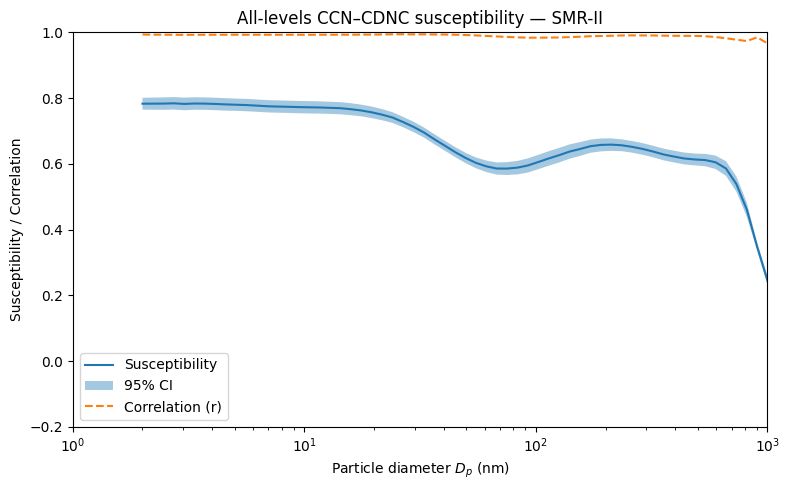

In [6]:
station = "SMR-II"
sl = reg_ds["slope"].sel(station=station)
se = reg_ds["std_err"].sel(station=station)
rv = reg_ds["r_value"].sel(station=station)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(RADII * 2, sl, label="Susceptibility")
ax.fill_between(RADII * 2, sl - CI_Z * se, sl + CI_Z * se,
                alpha=0.4, label="95% CI")
ax.plot(RADII * 2, rv, "--", label="Correlation (r)")
ax.set_xscale("log")
ax.set_xlim([1, 1000])
ax.set_ylim([-0.2, 1])
ax.set_xlabel(r"Particle diameter $D_p$ (nm)")
ax.set_ylabel("Susceptibility / Correlation")
ax.set_title(f"All-levels CCN–CDNC susceptibility — {station}")
ax.legend()
fig.tight_layout()
plt.show()

## 4 · Per-level susceptibility (height × diameter)

Run the slope per level (sample dim = time only), giving a
`(station, radius, lev)` field. Plotted as a height–diameter mesh per station
using the mean pressure profile.

In [7]:
reg_ds_lev = susceptibility(
    CCN_CDNC_ds["CCN"], CCN_CDNC_ds["CDNC"], sample_dims=["time"]
).compute()

# Optional cache:
# reg_ds_lev.to_netcdf("/share/pech2273/EC_Earth_Susceptibility_By_Levels.nc")

### Figure 2 — Susceptibility with height and diameter, per station

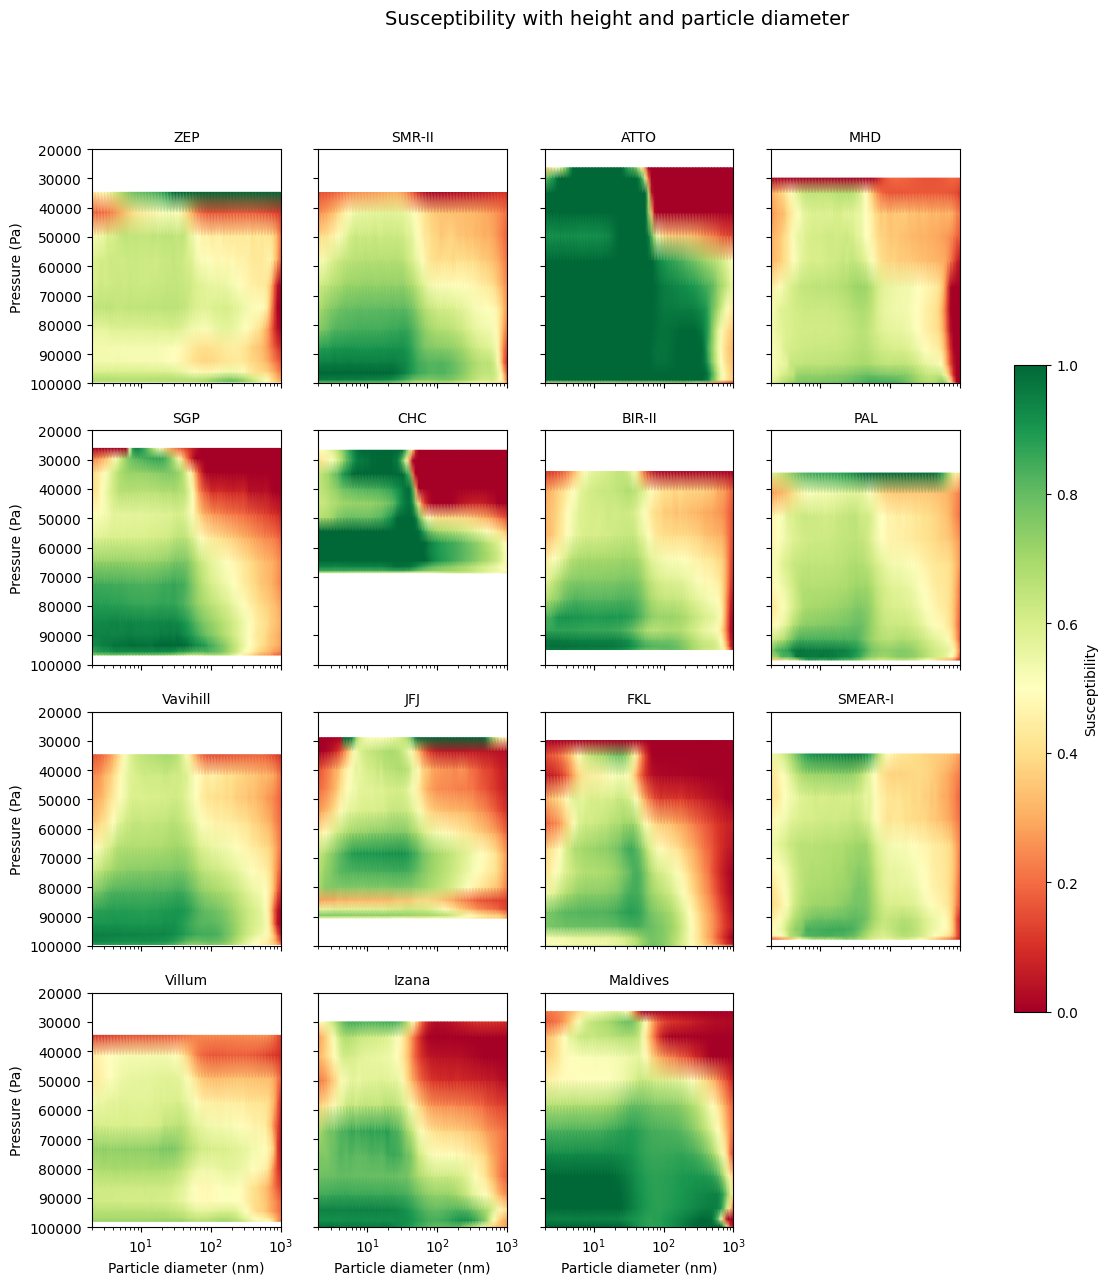

In [8]:
fig, axes = plt.subplots(4, 4, figsize=(14, 14), sharex=True, sharey=True)
axes = axes.flatten()
mesh = None
for i, station in enumerate(stations):
    ax = axes[i]
    mesh = ax.pcolormesh(
        reg_ds_lev["radius"] * 2,
        ds["pressure"].sel(station=station).mean("time"),
        reg_ds_lev["slope"].sel(station=station).T,
        shading="gouraud", vmin=0, vmax=1, cmap="RdYlGn")
    ax.set_title(station, fontsize=10)
    ax.set_xscale("log")
    ax.set_xlim(2, 1000)
    ax.set_ylim([100000, 20000])         # Pa, surface at bottom
for j in range(len(stations), len(axes)):
    axes[j].axis("off")
for ax in axes[12:16]:
    ax.set_xlabel("Particle diameter (nm)")
for ax in axes[::4]:
    ax.set_ylabel("Pressure (Pa)")
if mesh is not None:
    fig.colorbar(mesh, ax=axes, shrink=0.6, label="Susceptibility")
fig.suptitle("Susceptibility with height and particle diameter", fontsize=14)
plt.show()

### Figure 3 — Susceptibility vs pressure at one diameter (SMR-II)

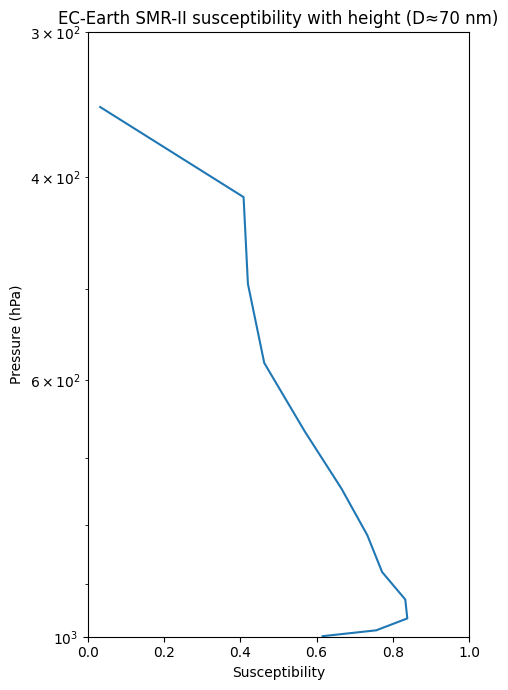

In [9]:
slope = reg_ds_lev["slope"].sel(station="SMR-II").sel(radius=35, method="nearest")
pressure = ds["pressure"].sel(station="SMR-II").mean("time") / 100.0   # hPa

fig, ax = plt.subplots(figsize=(5, 7))
ax.plot(slope, pressure)
ax.set_xlim([0, 1])
ax.set_ylim([1000, 300])
ax.set_yscale("log")
ax.set_xlabel("Susceptibility")
ax.set_ylabel("Pressure (hPa)")
ax.set_title("EC-Earth SMR-II susceptibility with height (D≈70 nm)")
fig.tight_layout()
plt.show()

## 5 · Column-integrated susceptibility

Sum CCN and CDNC over cloudy levels (CDNC > 0) into a column burden, then run
the same slope. Compared against the all-levels result per station.

In [10]:
masked = CCN_CDNC_ds.where(CCN_CDNC_ds["CDNC"] > 0)
CCN_column  = masked["CCN"].sum("lev")
CDNC_column = masked["CDNC"].sum("lev")

reg_ds_column = susceptibility(
    CCN_column, CDNC_column, sample_dims=["time"]
).compute()

### Figure 4 — Column vs all-levels susceptibility, per station

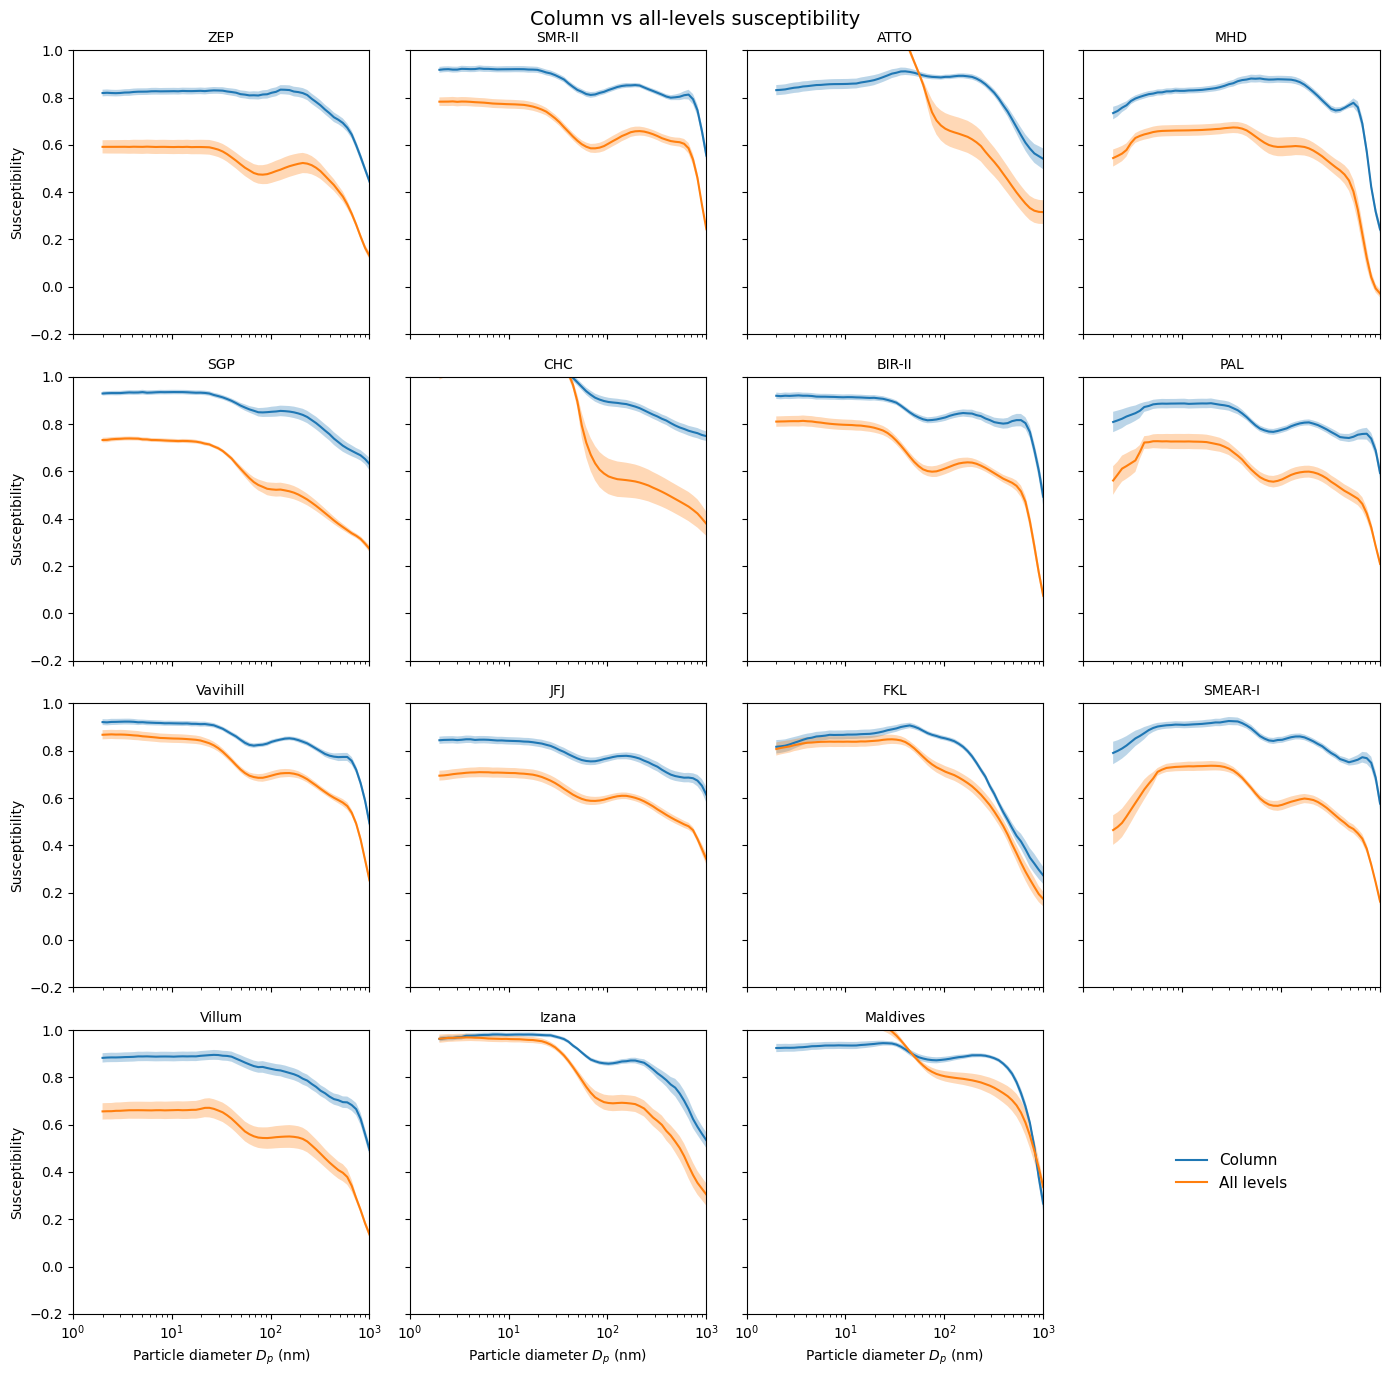

In [11]:
fig, axes = plt.subplots(4, 4, figsize=(14, 14), sharex=True, sharey=True)
axes = axes.flatten()
for i, station in enumerate(stations):
    ax = axes[i]
    for d, label in [(reg_ds_column, "Column"), (reg_ds, "All levels")]:
        sl = d["slope"].sel(station=station)
        se = d["std_err"].sel(station=station)
        ax.plot(RADII * 2, sl, label=label)
        ax.fill_between(RADII * 2, sl - CI_Z * se, sl + CI_Z * se, alpha=0.3)
    ax.set_title(station, fontsize=10)
    ax.set_xscale("log")
    ax.set_xlim([1, 1000])
    ax.set_ylim([-0.2, 1])
for j in range(len(stations), len(axes)):
    axes[j].axis("off")
if len(stations) < len(axes):
    h, l = axes[0].get_legend_handles_labels()
    axes[-1].legend(h, l, loc="center", frameon=False, fontsize=11)
for ax in axes[12:16]:
    ax.set_xlabel(r"Particle diameter $D_p$ (nm)")
for ax in axes[::4]:
    ax.set_ylabel("Susceptibility")
fig.suptitle("Column vs all-levels susceptibility", fontsize=14)
plt.tight_layout()
plt.show()

## 6 · Per-bin aggregation comparison

The susceptibility slope can shift with the per-bin statistic. Recompute the
column susceptibility with each `bin_stat` (median, mean, max, min) and compare
the station-mean spectra. Median is the default used elsewhere; this shows how
sensitive the result is to that choice.

In [12]:
agg_methods = ["median", "mean", "max", "min"]
reg_by_agg = {
    agg: susceptibility(CCN_column, CDNC_column,
                        sample_dims=["time"], bin_stat=agg).compute()
    for agg in agg_methods
}
print("computed:", list(reg_by_agg))

computed: ['median', 'mean', 'max', 'min']


### Figure 5 — Station-mean susceptibility by aggregation statistic

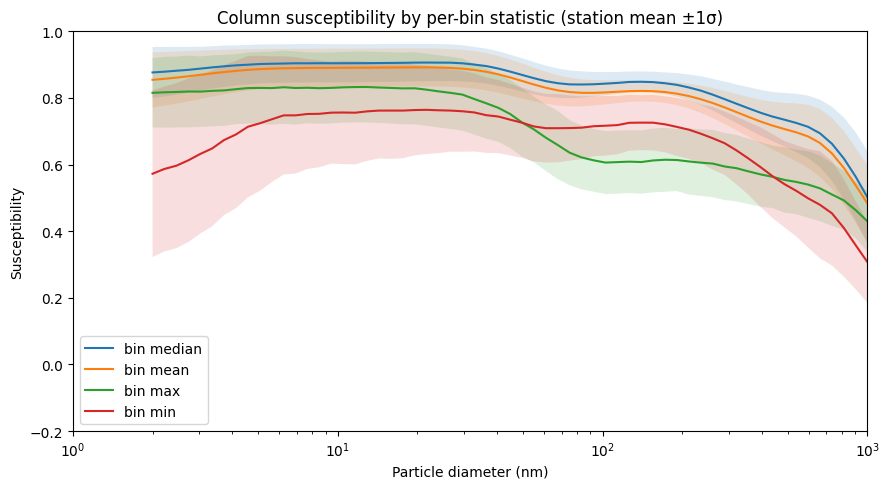

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
for agg in agg_methods:
    d = reg_by_agg[agg]
    mean_sl = d["slope"].mean("station")
    std_sl  = d["slope"].std("station")
    ax.plot(RADII * 2, mean_sl, label=f"bin {agg}")
    ax.fill_between(RADII * 2, mean_sl - std_sl, mean_sl + std_sl, alpha=0.15)
ax.set_xscale("log")
ax.set_xlim([1, 1000])
ax.set_ylim([-0.2, 1])
ax.set_xlabel("Particle diameter (nm)")
ax.set_ylabel("Susceptibility")
ax.set_title("Column susceptibility by per-bin statistic (station mean ±1σ)")
ax.legend()
fig.tight_layout()
plt.show()

## 7 · Aitken-to-accumulation ratio clustering

`AitAccRatio = N20 / N100` where `N20` is the count between 20 and 100 nm
diameter and `N100` is the count above 100 nm. Stations are clustered by their
surface-level ratio with k-means; the elbow curve motivates `N_CLUSTERS`.

In [14]:
AitAcc_ds = Function.ECEarthERF(ds, [20, 100])
N100 = AitAcc_ds.sel(radius=100)
N20  = AitAcc_ds.sel(radius=20) - AitAcc_ds.sel(radius=100)
AitAccRatio = N20 / N100

### Figure 6 — K-means elbow curve

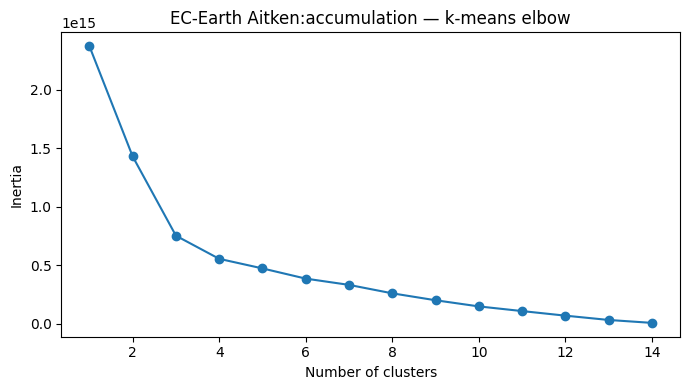

In [15]:
ratio_surface = AitAccRatio.isel(lev=-1).dropna("time")

inertias = []
for k in range(1, 15):
    km = KMeans(n_clusters=k, random_state=2, init="k-means++")
    km.fit(ratio_surface)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, 15), inertias, marker="o")
ax.set_xlabel("Number of clusters")
ax.set_ylabel("Inertia")
ax.set_title("EC-Earth Aitken:accumulation — k-means elbow")
fig.tight_layout()
plt.show()

### Cluster assignment

Fit with `N_CLUSTERS` and print the station membership of each group.

In [16]:
km = KMeans(n_clusters=N_CLUSTERS, random_state=2, init="k-means++")
km.fit(ratio_surface)

kmeans_aitacc = ratio_surface.to_dataset()
kmeans_aitacc["label"] = xr.DataArray(km.labels_, dims=("station",))

for g in range(N_CLUSTERS):
    members = kmeans_aitacc.station.where(kmeans_aitacc.label == g).dropna("station")
    print(f"Group {g + 1}: {members.values}")

Group 1: ['SMR-II' 'MHD' 'BIR-II' 'Vavihill']
Group 2: ['ATTO' 'SGP' 'CHC' 'JFJ' 'FKL' 'Izana' 'Maldives']
Group 3: ['ZEP' 'Villum']
Group 4: ['PAL' 'SMEAR-I']


## 8 · Piecewise (two-breakpoint) structure of the susceptibility curve

A single power-law slope may hide structure: susceptibility often rises, then
plateaus, then falls across diameter. We fit a two-breakpoint piecewise linear
model to each station's slope-vs-$\log_{10}D$ curve to recover the segment
slopes (`alpha1`, `alpha2`, `alpha3`) and breakpoints.

This uses `piecewise_regression` over each `(station, radius)` slice. The fit is
expensive; it runs once and is cached in `pw_ds`.

In [17]:
# Drop levels that are entirely empty across stations/time before pooling
valid_levs = CCN_CDNC_ds["CDNC"].notnull().any(dim=["station", "time"])
CCN_CDNC_valid = CCN_CDNC_ds.sel(lev=valid_levs)

In [18]:
import piecewise_regression

PARAMS    = ["const", "beta1", "beta2", "alpha1", "alpha2", "alpha3",
             "breakpoint1", "breakpoint2"]
STAT_KEYS = ["estimate", "se", "ci_lower", "ci_upper"]
N_OUTPUTS = len(PARAMS) * 4 + 4           # 4 stats per param + bic/rss/davies/converged


def fit_piecewise_1d(ccn, cdnc, n_bins=N_BINS):
    """Two-breakpoint piecewise fit of log-CDNC vs log-CCN for one slice.

    Logs first, equal-number bins (median per bin), then fits two breakpoints.
    Returns a flat array of all parameter stats plus fit diagnostics; NaN-filled
    on failure or non-convergence.
    """
    out = np.full(N_OUTPUTS, np.nan)
    with np.errstate(divide="ignore", invalid="ignore"):
        lx, ly = np.log10(ccn), np.log10(cdnc)
    valid = np.isfinite(lx) & np.isfinite(ly)
    if valid.sum() < 6:
        return out

    lx, ly = lx[valid], ly[valid]
    # equal-number bin medians (same recipe as the linear slope)
    order = np.argsort(lx)
    lx_s, ly_s = lx[order], ly[order]
    nb = min(n_bins, lx_s.size)
    xc = np.fromiter((np.median(g) for g in np.array_split(lx_s, nb)), float, nb)
    yc = np.fromiter((np.median(g) for g in np.array_split(ly_s, nb)), float, nb)
    good = np.isfinite(xc) & np.isfinite(yc)
    xc, yc = xc[good], yc[good]
    if len(xc) < 6:
        return out

    try:
        pw_result = piecewise_regression.Fit(xc, yc, n_breakpoints=2).get_results()
    except Exception:
        return out
    if not pw_result["converged"]:
        return out

    estimates = pw_result["estimates"]
    for i, p in enumerate(PARAMS):
        est = estimates.get(p)
        if est is None:
            continue
        base = i * 4
        out[base]     = est["estimate"]
        out[base + 1] = est["se"]
        out[base + 2] = est["confidence_interval"][0]
        out[base + 3] = est["confidence_interval"][1]

    base = len(PARAMS) * 4
    out[base]     = pw_result["bic"]
    out[base + 1] = pw_result["rss"]
    out[base + 2] = pw_result["davies"]
    out[base + 3] = float(pw_result["converged"])
    return out


# Pool time x lev into one sample dim, broadcast CDNC across radius
ccn_st  = CCN_CDNC_valid["CCN"].stack(sample=("time", "lev")).chunk({"sample": -1})
cdnc_st = (CCN_CDNC_valid["CDNC"].stack(sample=("time", "lev"))
           .expand_dims({"radius": ccn_st.radius}).chunk({"sample": -1}))

raw = xr.apply_ufunc(
    fit_piecewise_1d, ccn_st, cdnc_st,
    input_core_dims=[["sample"], ["sample"]],
    output_core_dims=[["output"]],
    dask_gufunc_kwargs={"output_sizes": {"output": N_OUTPUTS}},
    vectorize=True, dask="parallelized", output_dtypes=[float],
).compute()

# Split the flat output axis into named variables
pw_ds = xr.Dataset()
for i, p in enumerate(PARAMS):
    for j, s in enumerate(STAT_KEYS):
        pw_ds[f"{p}_{s}"] = raw.isel(output=i * 4 + j)
base = len(PARAMS) * 4
pw_ds["bic"]       = raw.isel(output=base)
pw_ds["rss"]       = raw.isel(output=base + 1)
pw_ds["davies"]    = raw.isel(output=base + 2)
pw_ds["converged"] = raw.isel(output=base + 3).astype(bool)
pw_ds

<xarray.Dataset> Size: 258kB
Dimensions:               (station: 15, radius: 61)
Coordinates:
  * station               (station) <U8 480B 'ZEP' 'SMR-II' ... 'Maldives'
  * radius                (radius) float64 488B 1.0 1.109 1.23 ... 451.9 501.2
Data variables: (12/36)
    const_estimate        (radius, station) float64 7kB 1.477 0.2968 ... 2.343
    const_se              (radius, station) float64 7kB 0.03961 ... 0.008267
    const_ci_lower        (radius, station) float64 7kB 1.398 0.2378 ... 2.327
    const_ci_upper        (radius, station) float64 7kB 1.556 0.3558 ... 2.36
    beta1_estimate        (radius, station) float64 7kB 0.6595 0.168 ... 0.2455
    beta1_se              (radius, station) float64 7kB 0.02528 ... 0.04436
    ...                    ...
    breakpoint2_ci_lower  (radius, station) float64 7kB 2.377 3.153 ... -0.1857
    breakpoint2_ci_upper  (radius, station) float64 7kB 2.506 3.2 ... -0.08426
    bic                   (radius, station) float64 7kB -891.2 -921.5 ... -742.9
    rss                   (radius, station) float64 7kB 0.01022 ... 0.04502
    davies                (radius, station) float64 7kB 1.806e-137 ... 1.208e-73
    converged             (radius, station) bool 915B True True ... True True

### Figure 7 — Piecewise segment slopes per station

The three segment slopes (`alpha1`, `alpha2`, `alpha3`) with 95% bands vs
diameter, one panel per station.

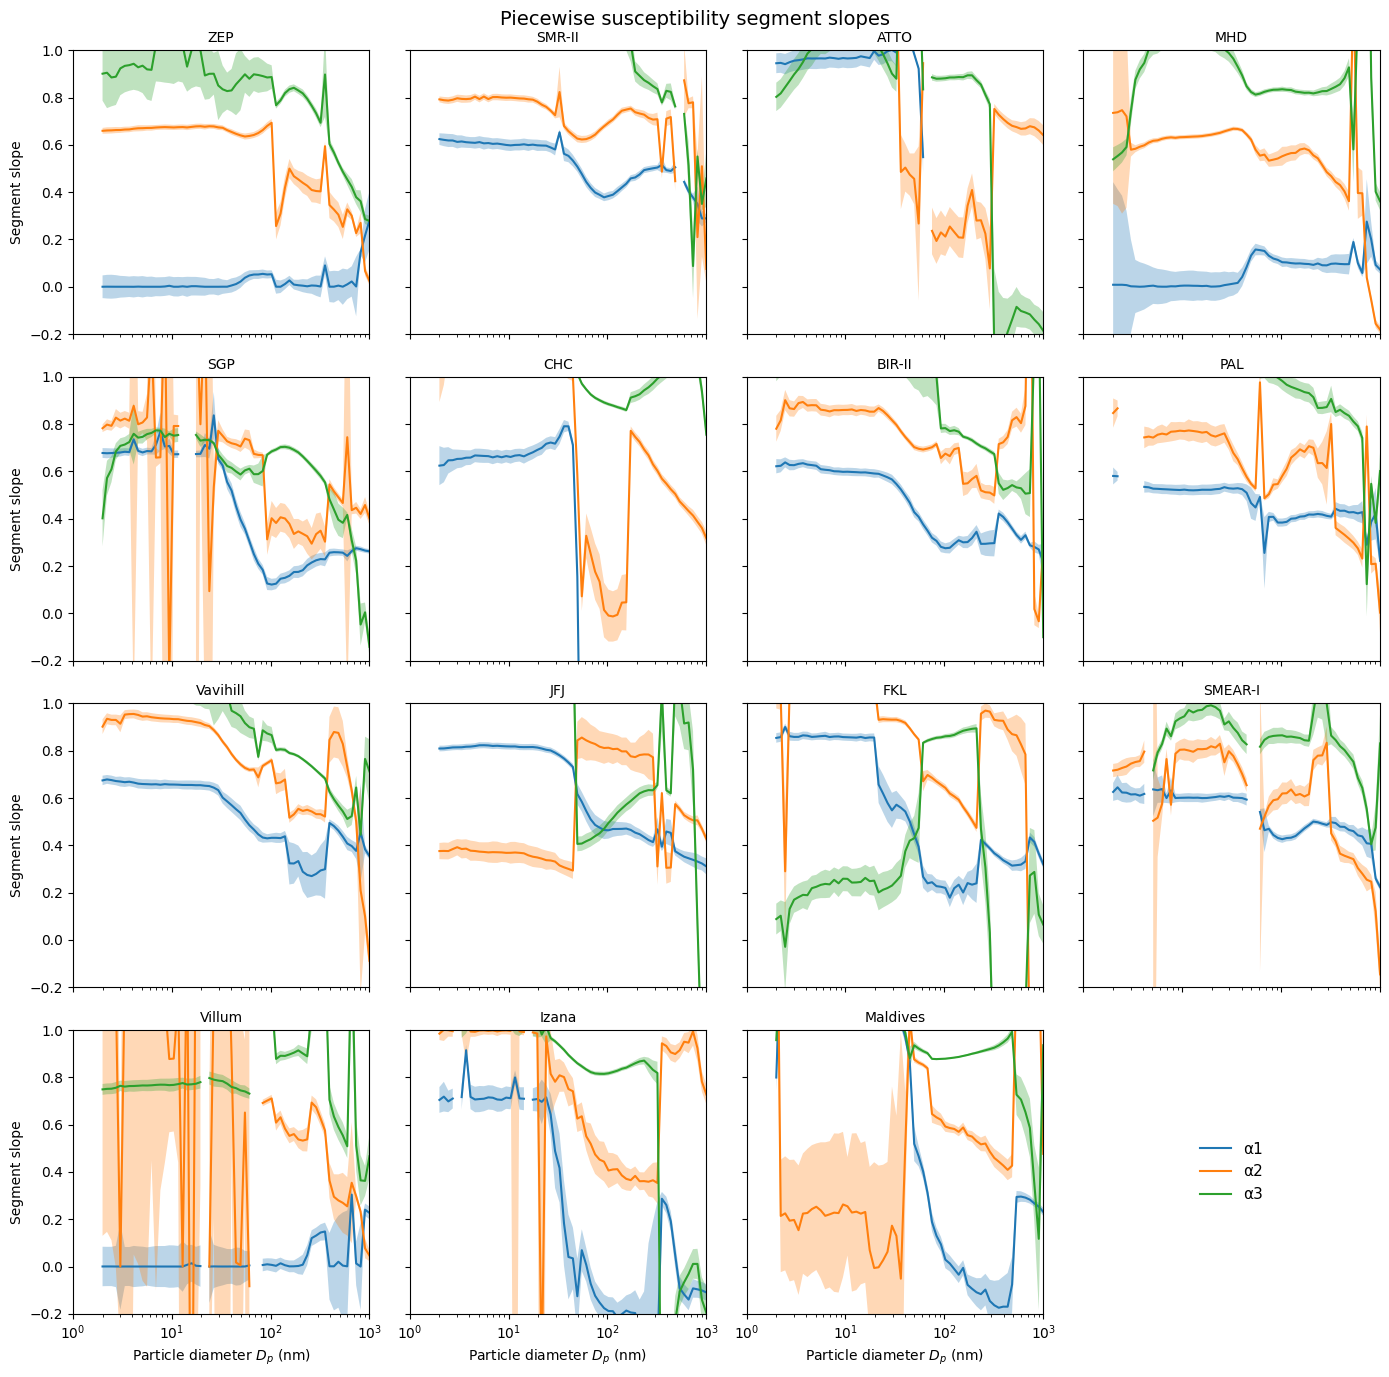

In [19]:
fig, axes = plt.subplots(4, 4, figsize=(14, 14), sharex=True, sharey=True)
axes = axes.flatten()
seg = [("alpha1_estimate", "alpha1_se", "α1"),
       ("alpha2_estimate", "alpha2_se", "α2"),
       ("alpha3_estimate", "alpha3_se", "α3")]
for i, station in enumerate(pw_ds.station.values):
    ax = axes[i]
    for est_k, se_k, label in seg:
        sl = pw_ds[est_k].sel(station=station)
        se = pw_ds[se_k].sel(station=station)
        ax.plot(RADII * 2, sl, label=label)
        ax.fill_between(RADII * 2, sl - CI_Z * se, sl + CI_Z * se, alpha=0.3)
    ax.set_title(station, fontsize=10)
    ax.set_xscale("log")
    ax.set_xlim([1, 1000])
    ax.set_ylim([-0.2, 1])
for j in range(len(pw_ds.station), len(axes)):
    axes[j].axis("off")
if len(pw_ds.station) < len(axes):
    h, l = axes[0].get_legend_handles_labels()
    axes[-1].legend(h, l, loc="center", frameon=False, fontsize=11)
for ax in axes[12:16]:
    ax.set_xlabel(r"Particle diameter $D_p$ (nm)")
for ax in axes[::4]:
    ax.set_ylabel("Segment slope")
fig.suptitle("Piecewise susceptibility segment slopes", fontsize=14)
plt.tight_layout()
plt.show()